# ⚖️ Class Imbalance Toolkit

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/imbalance-toolkit/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/imbalance-toolkit/demo.ipynb)

> **"Our fraud model ignores the minority class."**

A classifier trained on 3%-fraud data can hit **98% accuracy by predicting "not fraud" every single time** — and catch zero fraud. This notebook shows the trap and compares four fixes, ranked by the metric that actually matters when the rare class is the one you care about: **minority-class recall**.

**What we cover**
1. Build a realistic imbalanced fraud dataset
2. Measure how skewed it is
3. Train four strategies on the *same* split: Baseline · Class Weights · SMOTE · Random Undersample
4. Rank them by recall + PR-AUC (not accuracy)
5. Visualize the recall/precision trade-off
6. Read the one-line recommendation


## Step 1 — A rare positive class

Fraud, churn, defects, disease: the interesting class is almost always the rare one. We synthesize 4,000 transactions where only ~3% are fraud. Fraud rows are shifted in feature space so they're *learnable* but *rare* — the honest hard case.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

def make_sample_data(n=4000, fraud_rate=0.03, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n_fraud = max(1, int(round(n * fraud_rate)))
    n_legit = n - n_fraud
    legit = rng.normal(0.0, 1.0, size=(n_legit, 4))
    fraud = rng.normal(1.4, 1.3, size=(n_fraud, 4))
    X = np.vstack([legit, fraud])
    y = np.concatenate([np.zeros(n_legit, dtype=int), np.ones(n_fraud, dtype=int)])
    df = pd.DataFrame(X, columns=["amount_z", "velocity_z", "geo_risk", "device_age_z"])
    df["is_fraud"] = y
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

df = make_sample_data()
df.head()

,amount_z,velocity_z,geo_risk,device_age_z,is_fraud
0,0.092679,-0.768356,0.085993,-0.794044,0
1,0.424295,-0.306230,-1.037463,-0.569893,0
2,-0.798153,0.211386,0.390455,0.496343,0
3,1.398174,-0.390311,0.957652,2.188656,1
4,0.162962,-0.462765,2.862264,0.155825,0


## Step 2 — How bad is the imbalance?

The imbalance ratio tells you what you're up against. 32:1 means for every fraud case there are 32 legit ones — plenty of room for a lazy model to hide.

In [2]:
def imbalance_report(df, target):
    counts = df[target].value_counts().sort_index()
    minority, majority, total = int(counts.min()), int(counts.max()), int(counts.sum())
    return {
        "total_rows": total,
        "minority_count": minority,
        "majority_count": majority,
        "minority_pct": round(100 * minority / total, 3),
        "imbalance_ratio": round(majority / max(1, minority), 1),
    }

rep = imbalance_report(df, "is_fraud")
for k, v in rep.items():
    print(f"{k:>16}: {v}")

      total_rows: 4000
  minority_count: 120
  majority_count: 3880
    minority_pct: 3.0
 imbalance_ratio: 32.3


## Step 3 — Four strategies, one fair split

Every strategy uses the *same* train/test split and the same LogisticRegression classifier. The only thing that changes is **how we handle the imbalance** during training:

| Strategy | What it does |
|---|---|
| **Baseline** | Nothing — train as-is |
| **Class Weights** | `class_weight="balanced"` — penalize minority errors more |
| **SMOTE** | Synthesize new minority samples until classes balance |
| **Random Undersample** | Throw away majority rows until classes balance |

Note SMOTE / undersampling live *inside* an `imblearn` pipeline so resampling happens on the training fold only — never leaking into the test set.

In [3]:
def build_estimators():
    lr = lambda **kw: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kw)
    return {
        "Baseline": ImbPipeline([("scale", StandardScaler()), ("clf", lr())]),
        "Class Weights": ImbPipeline([("scale", StandardScaler()), ("clf", lr(class_weight="balanced"))]),
        "SMOTE": ImbPipeline([("scale", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", lr())]),
        "Random Undersample": ImbPipeline([("scale", StandardScaler()), ("under", RandomUnderSampler(random_state=RANDOM_STATE)), ("clf", lr())]),
    }

def score(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": round((tp + tn) / max(1, tp + tn + fp + fn), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc": round(average_precision_score(y_true, y_prob), 4),
        "true_pos": int(tp), "false_neg": int(fn), "false_pos": int(fp),
    }

X, y = df.drop(columns=["is_fraud"]), df["is_fraud"].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

rows, probs = [], {}
for name, est in build_estimators().items():
    est.fit(X_tr, y_tr)
    p = est.predict_proba(X_te)[:, 1]
    m = score(y_te, (p >= 0.5).astype(int), p)
    m["strategy"] = name
    rows.append(m); probs[name] = p

cols = ["recall", "precision", "f1", "pr_auc", "roc_auc", "accuracy", "true_pos", "false_neg", "false_pos"]
board = pd.DataFrame(rows).set_index("strategy")[cols].sort_values(["recall", "pr_auc"], ascending=False)
board

,recall,precision,f1,pr_auc,roc_auc,accuracy,true_pos,false_neg,false_pos
strategy,,,,,,,,,
Class Weights,0.8889,0.2025,0.3299,0.6749,0.9539,0.8917,32,4,126
SMOTE,0.8889,0.2051,0.3333,0.6723,0.9538,0.8933,32,4,124
Random Undersample,0.8889,0.2013,0.3282,0.6503,0.9505,0.8908,32,4,127
Baseline,0.5278,0.8636,0.6552,0.6794,0.9486,0.9833,19,17,3


## Step 4 — Read the leaderboard, not the accuracy

Look at **Baseline**: highest accuracy, but it *misses most of the fraud* (low recall, high `false_neg`). The rebalanced strategies catch far more fraud — at the cost of more false alarms. That trade-off is the whole game.

In [4]:
base = board.loc["Baseline"]
best = board.iloc[0]
print(f"Baseline:  caught {int(base['true_pos'])} fraud, MISSED {int(base['false_neg'])}  (recall {base['recall']:.0%}, accuracy {base['accuracy']:.0%})")
print(f"{board.index[0]}:  caught {int(best['true_pos'])} fraud, MISSED {int(best['false_neg'])}  (recall {best['recall']:.0%}, accuracy {best['accuracy']:.0%})")
print()
print("The high-accuracy model is the one that lets the most fraud through.")

Baseline:  caught 19 fraud, MISSED 17  (recall 53%, accuracy 98%)
Class Weights:  caught 32 fraud, MISSED 4  (recall 89%, accuracy 89%)

The high-accuracy model is the one that lets the most fraud through.


## Step 5 — Visualize the recall vs precision trade-off

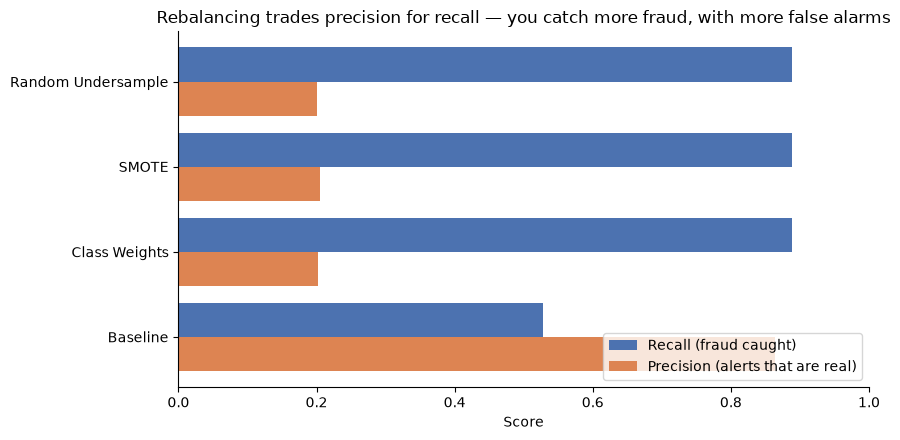

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
bs = board.sort_values("recall")
yp = np.arange(len(bs))
ax.barh(yp + 0.2, bs["recall"], height=0.4, color="#4C72B0", label="Recall (fraud caught)")
ax.barh(yp - 0.2, bs["precision"], height=0.4, color="#DD8452", label="Precision (alerts that are real)")
ax.set_yticks(yp); ax.set_yticklabels(bs.index)
ax.set_xlabel("Score"); ax.set_xlim(0, 1)
ax.set_title("Rebalancing trades precision for recall — you catch more fraud, with more false alarms")
ax.legend(loc="lower right")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6 — The recommendation

Rank by recall, report the lift over baseline and the precision cost, in one line.

In [6]:
def recommend(board):
    best = board.index[0]
    base_recall = float(board.loc["Baseline", "recall"]) if "Baseline" in board.index else 0.0
    best_recall = float(board.loc[best, "recall"])
    prec = float(board.loc[best, "precision"])
    return (f"Use {best}: catches {best_recall:.0%} of the minority class "
            f"(+{best_recall - base_recall:.0%} vs baseline) at {prec:.0%} precision.")

print(recommend(board))

Use Class Weights: catches 89% of the minority class (+36% vs baseline) at 20% precision.


## Summary

- **Accuracy is a trap on imbalanced data.** The baseline scored highest on accuracy while missing the most fraud.
- **Class weights are the cheapest fix** — one parameter, no resampling, usually competitive with SMOTE.
- **Rank by recall + PR-AUC** for rare-class problems, and **tune the decision threshold** on PR-AUC when false-positive cost is high.
- SMOTE and undersampling belong *inside* the pipeline so resampling never leaks into your test set.

## 🔧 Try Your Own

Swap in your own CSV and target column:

In [7]:
# my_df = pd.read_csv("your_data.csv")
# TARGET = "your_binary_target"      # must be 0/1
#
# rep = imbalance_report(my_df, TARGET)
# print(rep)
#
# X = my_df.drop(columns=[TARGET]); y = my_df[TARGET].to_numpy()
# X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# rows = []
# for name, est in build_estimators().items():
#     est.fit(X_tr, y_tr)
#     p = est.predict_proba(X_te)[:, 1]
#     m = score(y_te, (p >= 0.5).astype(int), p); m["strategy"] = name; rows.append(m)
# out = pd.DataFrame(rows).set_index("strategy").sort_values("recall", ascending=False)
# print(recommend(out)); out

---

Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — a daily FDE portfolio (Day 74 of 120).

**Prefer a UI?** Run the Streamlit app: `pip install -r requirements.txt && streamlit run app.py` — upload a CSV, pick the target, compare strategies interactively.